In [1]:
import cv2
import numpy as np
from matplotlib import pyplot as plt

print(cv2.__version__)

4.9.0


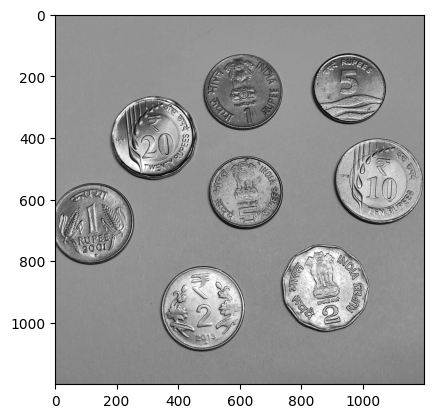

In [5]:
image = cv2.imread("coin.jpg", 0)
plt.imshow(image, "gray")

In [33]:
def RegionGrowing(image, seed_point=(1000, 500), eight_neighbors=True, threshold=20):
    height, width = image.shape
    segmented = np.zeros_like(image, dtype=np.uint8)
    visited = np.zeros_like(image, dtype=np.uint8)

    queue = list()
    queue.append(seed_point)
    visited[seed_point] = 1

    def SimilarityCriteria(pix1, pix2):
        pix1 = pix1.astype(np.int32)
        pix2 = pix2.astype(np.int32)
        return abs(pix1 - pix2) < threshold

    def get_eight_neighbors(pixel):
        x, y = pixel
        neighbors = [
            (x - 1, y - 1),
            (x - 1, y),
            (x - 1, y + 1),
            (x, y - 1),
            (x, y + 1),
            (x + 1, y - 1),
            (x + 1, y),
            (x + 1, y + 1),
        ]
        return [(i, j) for i, j in neighbors if 0 <= i < height and 0 <= j < width]

    def get_four_neighbors(pixel):
        x, y = pixel
        neighbors = [
            (x - 1, y),
            (x, y - 1),
            (x, y + 1),
            (x + 1, y),
        ]
        return [(i, j) for i, j in neighbors if 0 <= i < height and 0 <= j < width]

    neighbors_function = get_eight_neighbors if eight_neighbors else get_four_neighbors

    while queue:
        curr_pix = queue.pop(0)
        segmented[curr_pix] = image[curr_pix]

        neighbors = neighbors_function(curr_pix)
        for neighbor in neighbors:
            if visited[neighbor] == 0 and SimilarityCriteria(
                image[curr_pix], image[neighbor]
            ):
                queue.append(neighbor)
                visited[neighbor] = 1

    return segmented

In [34]:
segmented_image = RegionGrowing(image)
print("Segmented")

Segmented


Text(0.5, 1.0, 'Segmented image')

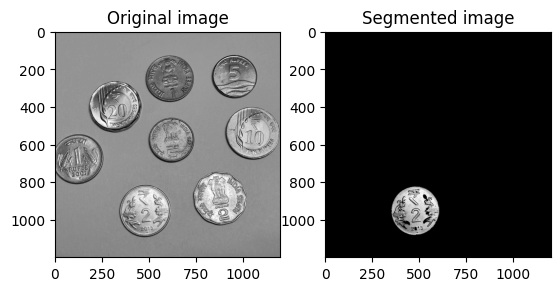

In [35]:
plt.subplot(1, 2, 1)
plt.imshow(image, "gray")
plt.title("Original image")

plt.subplot(1, 2, 2)
plt.imshow(segmented_image, "gray")
plt.title("Segmented image")

In [47]:
segmented_image_2 = RegionGrowing(image, seed_point=(550, 1060), threshold=20)
print("Segmented")

Segmented


Text(0.5, 1.0, 'Segmented image')

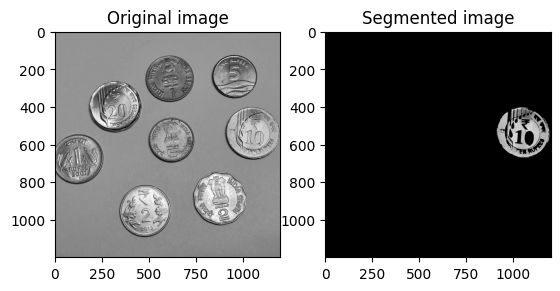

In [48]:
plt.subplot(1, 2, 1)
plt.imshow(image, "gray")
plt.title("Original image")

plt.subplot(1, 2, 2)
plt.imshow(segmented_image_2, "gray")
plt.title("Segmented image")

In [114]:
def add_gaussian_noise(image, mean=0, sigma=0.65):
    rows, cols = image.shape
    gaussian_noise = np.random.normal(mean, sigma, (rows, cols)).astype(np.uint8)

    noisy_image = cv2.add(image, gaussian_noise)

    return noisy_image

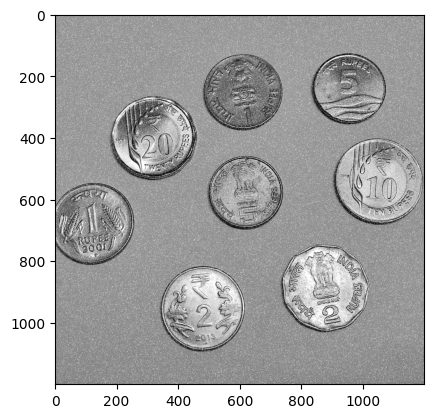

In [119]:
noisy_image = add_gaussian_noise(image, sigma=0.67)
plt.imshow(noisy_image, "gray")

In [122]:
segmented_image_3 = RegionGrowing(noisy_image, seed_point=(1000, 500), threshold=25)
print("segmented")

segmented


Text(0.5, 1.0, 'Segmented image')

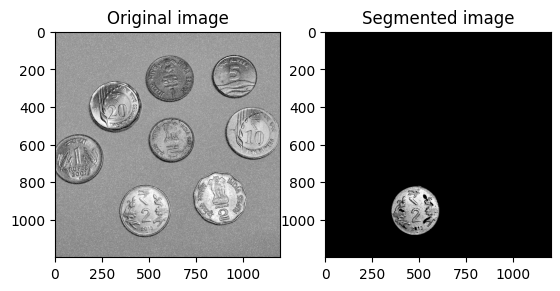

In [123]:
plt.subplot(1, 2, 1)
plt.imshow(noisy_image, "gray")
plt.title("Original image")

plt.subplot(1, 2, 2)
plt.imshow(segmented_image_3, "gray")
plt.title("Segmented image")